In [4]:
!pip install pandas numpy matplotlib


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 651.9 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/9.8 MB 651.9 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/9.8 MB 660.6 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/9.8 MB 708.8 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.8 MB 708.8 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.8 MB 740.6 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.8 MB 771.3 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/9.8 MB 804.0 kB/s eta 0:00:10
   -------- -------------------

# CXR Dataset — Load, Process & Visualize

**Dataset:** OpenI / Indiana University Chest X-ray Collection (NLM CXR)  
**Source archives:** `NLMCXR_png.tgz` (images) · `NLMCXR_reports.tgz` (radiology reports as XML)  

---
### Notebook outline
1. Extract archives  
2. Parse XML reports → DataFrame  
3. Dataset statistics  
4. Visualizations  
5. Side-by-side image + report viewer  

## 0 · Imports

In [5]:
import tarfile
import xml.etree.ElementTree as ET
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.image import imread
from textwrap import wrap

# Suppress matplotlib warnings
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')

Imports OK


## 1 · Extract Archives

In [6]:
BASE_DIR   = Path('.')            # project root (where the .tgz files live)
IMAGES_DIR = BASE_DIR / 'images'
REPORTS_DIR = BASE_DIR / 'reports'

def extract_if_needed(archive: Path, target: Path):
    if target.exists() and any(target.iterdir()):
        print(f'  {target} already extracted — skipping.')
        return
    target.mkdir(parents=True, exist_ok=True)
    print(f'  Extracting {archive.name} → {target} …')
    with tarfile.open(archive, 'r:gz') as tf:
        tf.extractall(path=target)
    print(f'  Done.')

extract_if_needed(BASE_DIR / 'NLMCXR_png.tgz',     IMAGES_DIR)
extract_if_needed(BASE_DIR / 'NLMCXR_reports.tgz', REPORTS_DIR)

# Locate actual sub-directories after extraction
image_files  = sorted(IMAGES_DIR.rglob('*.png'))
report_files = sorted((REPORTS_DIR).rglob('*.xml'))

print(f'\nImages  found : {len(image_files):,}')
print(f'Reports found : {len(report_files):,}')

  Extracting NLMCXR_png.tgz → images …
  Done.
  Extracting NLMCXR_reports.tgz → reports …
  Done.

Images  found : 7,470
Reports found : 3,955


## 2 · Parse XML Reports → DataFrame

In [7]:
# Build a lookup: image_id (no extension) → full path
image_lookup = {f.stem: f for f in image_files}

def parse_report(xml_path: Path) -> dict:
    """Extract structured fields from one NLM CXR XML report."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    uid_node = root.find('.//uId')
    uid = uid_node.get('id') if uid_node is not None else xml_path.stem

    # ---- report sections ----
    sections = {}
    for node in root.findall('.//AbstractText'):
        label = node.get('Label', '').upper()
        sections[label] = (node.text or '').strip()

    # ---- MeSH tags ----
    mesh_major = [n.text.strip() for n in root.findall('.//MeSH/major') if n.text]
    mesh_auto  = [n.text.strip() for n in root.findall('.//MeSH/automatic') if n.text]

    # ---- linked images ----
    parent_images = [n.get('id') for n in root.findall('.//parentImage') if n.get('id')]
    # resolve paths (strip leading 'CXRx_1_' variant vs 'CXRx_' variant both exist)
    image_paths = [str(image_lookup[pid]) for pid in parent_images if pid in image_lookup]

    return {
        'report_id'  : xml_path.stem,
        'uid'        : uid,
        'comparison' : sections.get('COMPARISON', ''),
        'indication' : sections.get('INDICATION', ''),
        'findings'   : sections.get('FINDINGS', ''),
        'impression'  : sections.get('IMPRESSION', ''),
        'mesh_major' : mesh_major,
        'mesh_auto'  : mesh_auto,
        'image_ids'  : parent_images,
        'image_paths': image_paths,
        'n_images'   : len(image_paths),
    }

records = [parse_report(p) for p in report_files]
df = pd.DataFrame(records)

print(f'DataFrame shape : {df.shape}')
df.head(3)

DataFrame shape : (3955, 11)


,report_id,uid,comparison,indication,findings,impression,mesh_major,mesh_auto,image_ids,image_paths,n_images
0,1,CXR1,None.,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,[normal],[],"[CXR1_1_IM-0001-3001, CXR1_1_IM-0001-4001]","[images\CXR1_1_IM-0001-3001.png, images\CXR1_1...",2
1,10,CXR10,Chest radiographs XXXX.,"XXXX-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,[Calcified Granuloma/lung/upper lobe/right],[calcified granuloma],"[CXR10_IM-0002-1001, CXR10_IM-0002-2001]","[images\CXR10_IM-0002-1001.png, images\CXR10_I...",2
2,100,CXR100,None.,,Both lungs are clear and expanded. Heart and m...,No active disease.,[normal],[],"[CXR100_IM-0002-1001, CXR100_IM-0002-2001]","[images\CXR100_IM-0002-1001.png, images\CXR100...",2


In [8]:
# Also build a flat per-image DataFrame (one row per image)
flat_rows = []
for _, row in df.iterrows():
    for img_id, img_path in zip(row['image_ids'], row['image_paths']):
        flat_rows.append({
            'report_id'  : row['report_id'],
            'uid'        : row['uid'],
            'image_id'   : img_id,
            'image_path' : img_path,
            'findings'   : row['findings'],
            'impression'  : row['impression'],
            'indication' : row['indication'],
            'comparison' : row['comparison'],
            'mesh_major' : row['mesh_major'],
        })

df_flat = pd.DataFrame(flat_rows)
print(f'Flat (per-image) DataFrame: {df_flat.shape}')
df_flat.head(3)

Flat (per-image) DataFrame: (7470, 9)


,report_id,uid,image_id,image_path,findings,impression,indication,comparison,mesh_major
0,1,CXR1,CXR1_1_IM-0001-3001,images\CXR1_1_IM-0001-3001.png,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Positive TB test,None.,[normal]
1,1,CXR1,CXR1_1_IM-0001-4001,images\CXR1_1_IM-0001-4001.png,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Positive TB test,None.,[normal]
2,10,CXR10,CXR10_IM-0002-1001,images\CXR10_IM-0002-1001.png,The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,"XXXX-year-old male, chest pain.",Chest radiographs XXXX.,[Calcified Granuloma/lung/upper lobe/right]


## 3 · Dataset Statistics

In [9]:
total_reports = len(df)
total_images  = len(df_flat)
matched_imgs  = df_flat['image_path'].notna().sum()

print('='*55)
print(f'  Total reports parsed         : {total_reports:>6,}')
print(f'  Total image files on disk    : {len(image_files):>6,}')
print(f'  Image–report pairs (matched) : {matched_imgs:>6,}')
print(f'  Reports with ≥1 image        : {(df["n_images"]>0).sum():>6,}')
print(f'  Reports with 0 images        : {(df["n_images"]==0).sum():>6,}')
print(f'  Avg images per report        : {df["n_images"].mean():>9.2f}')
print('='*55)

# Text length stats
for col in ['findings', 'impression', 'indication']:
    lens = df[col].str.split().str.len()
    print(f'  {col.capitalize():<12}  mean={lens.mean():.0f} words  max={lens.max()} words')

  Total reports parsed         :  3,955
  Total image files on disk    :  7,470
  Image–report pairs (matched) :  7,470
  Reports with ≥1 image        :  3,851
  Reports with 0 images        :    104
  Avg images per report        :      1.89
  Findings      mean=27 words  max=169 words
  Impression    mean=11 words  max=130 words
  Indication    mean=5 words  max=36 words


## 4 · Visualizations

### 4.1 Images-per-report distribution & text-length distributions

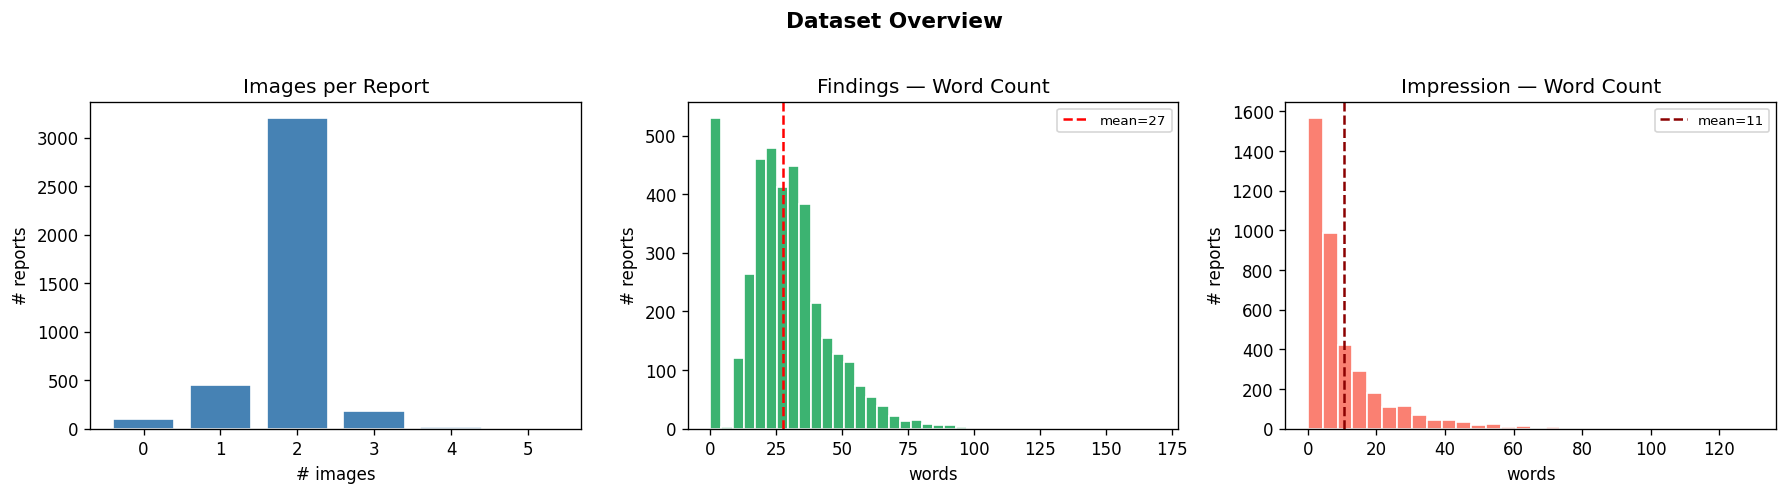

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# images per report
counts = df['n_images'].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Images per Report')
axes[0].set_xlabel('# images')
axes[0].set_ylabel('# reports')

# findings word count
findings_len = df['findings'].str.split().str.len().dropna()
axes[1].hist(findings_len, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Findings — Word Count')
axes[1].set_xlabel('words')
axes[1].set_ylabel('# reports')
axes[1].axvline(findings_len.mean(), color='red', linestyle='--', label=f'mean={findings_len.mean():.0f}')
axes[1].legend(fontsize=8)

# impression word count
impression_len = df['impression'].str.split().str.len().dropna()
axes[2].hist(impression_len, bins=30, color='salmon', edgecolor='white')
axes[2].set_title('Impression — Word Count')
axes[2].set_xlabel('words')
axes[2].set_ylabel('# reports')
axes[2].axvline(impression_len.mean(), color='darkred', linestyle='--', label=f'mean={impression_len.mean():.0f}')
axes[2].legend(fontsize=8)

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Top MeSH (diagnostic) tags

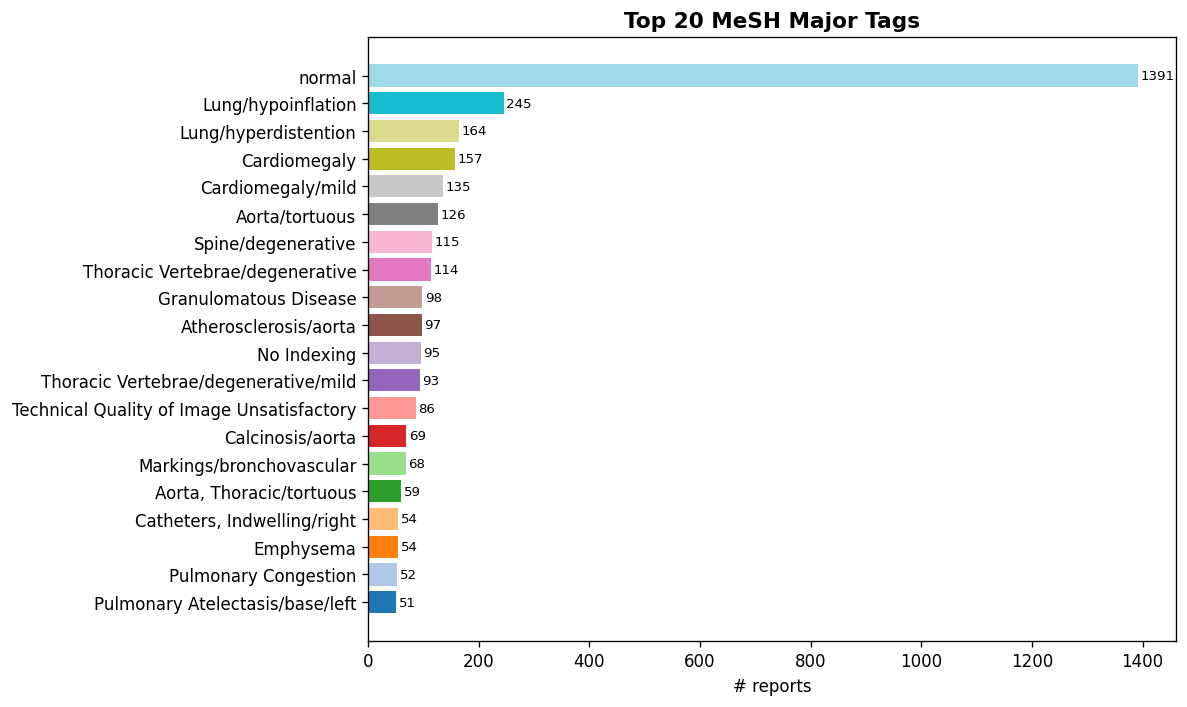

Unique MeSH major tags : 1719
Reports with "normal" tag : 1,391


In [11]:
all_mesh = [tag for tags in df['mesh_major'] for tag in tags]
mesh_counts = Counter(all_mesh)
top_n = 20
top_mesh = mesh_counts.most_common(top_n)
labels, values = zip(*top_mesh)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab20(range(top_n))
bars = ax.barh(labels[::-1], values[::-1], color=colors)
ax.set_xlabel('# reports')
ax.set_title(f'Top {top_n} MeSH Major Tags', fontsize=13, fontweight='bold')
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Unique MeSH major tags : {len(mesh_counts)}')
print(f'Reports with "normal" tag : {mesh_counts.get("normal", 0):,}')

### 4.3 Sample image grid (16 random images)

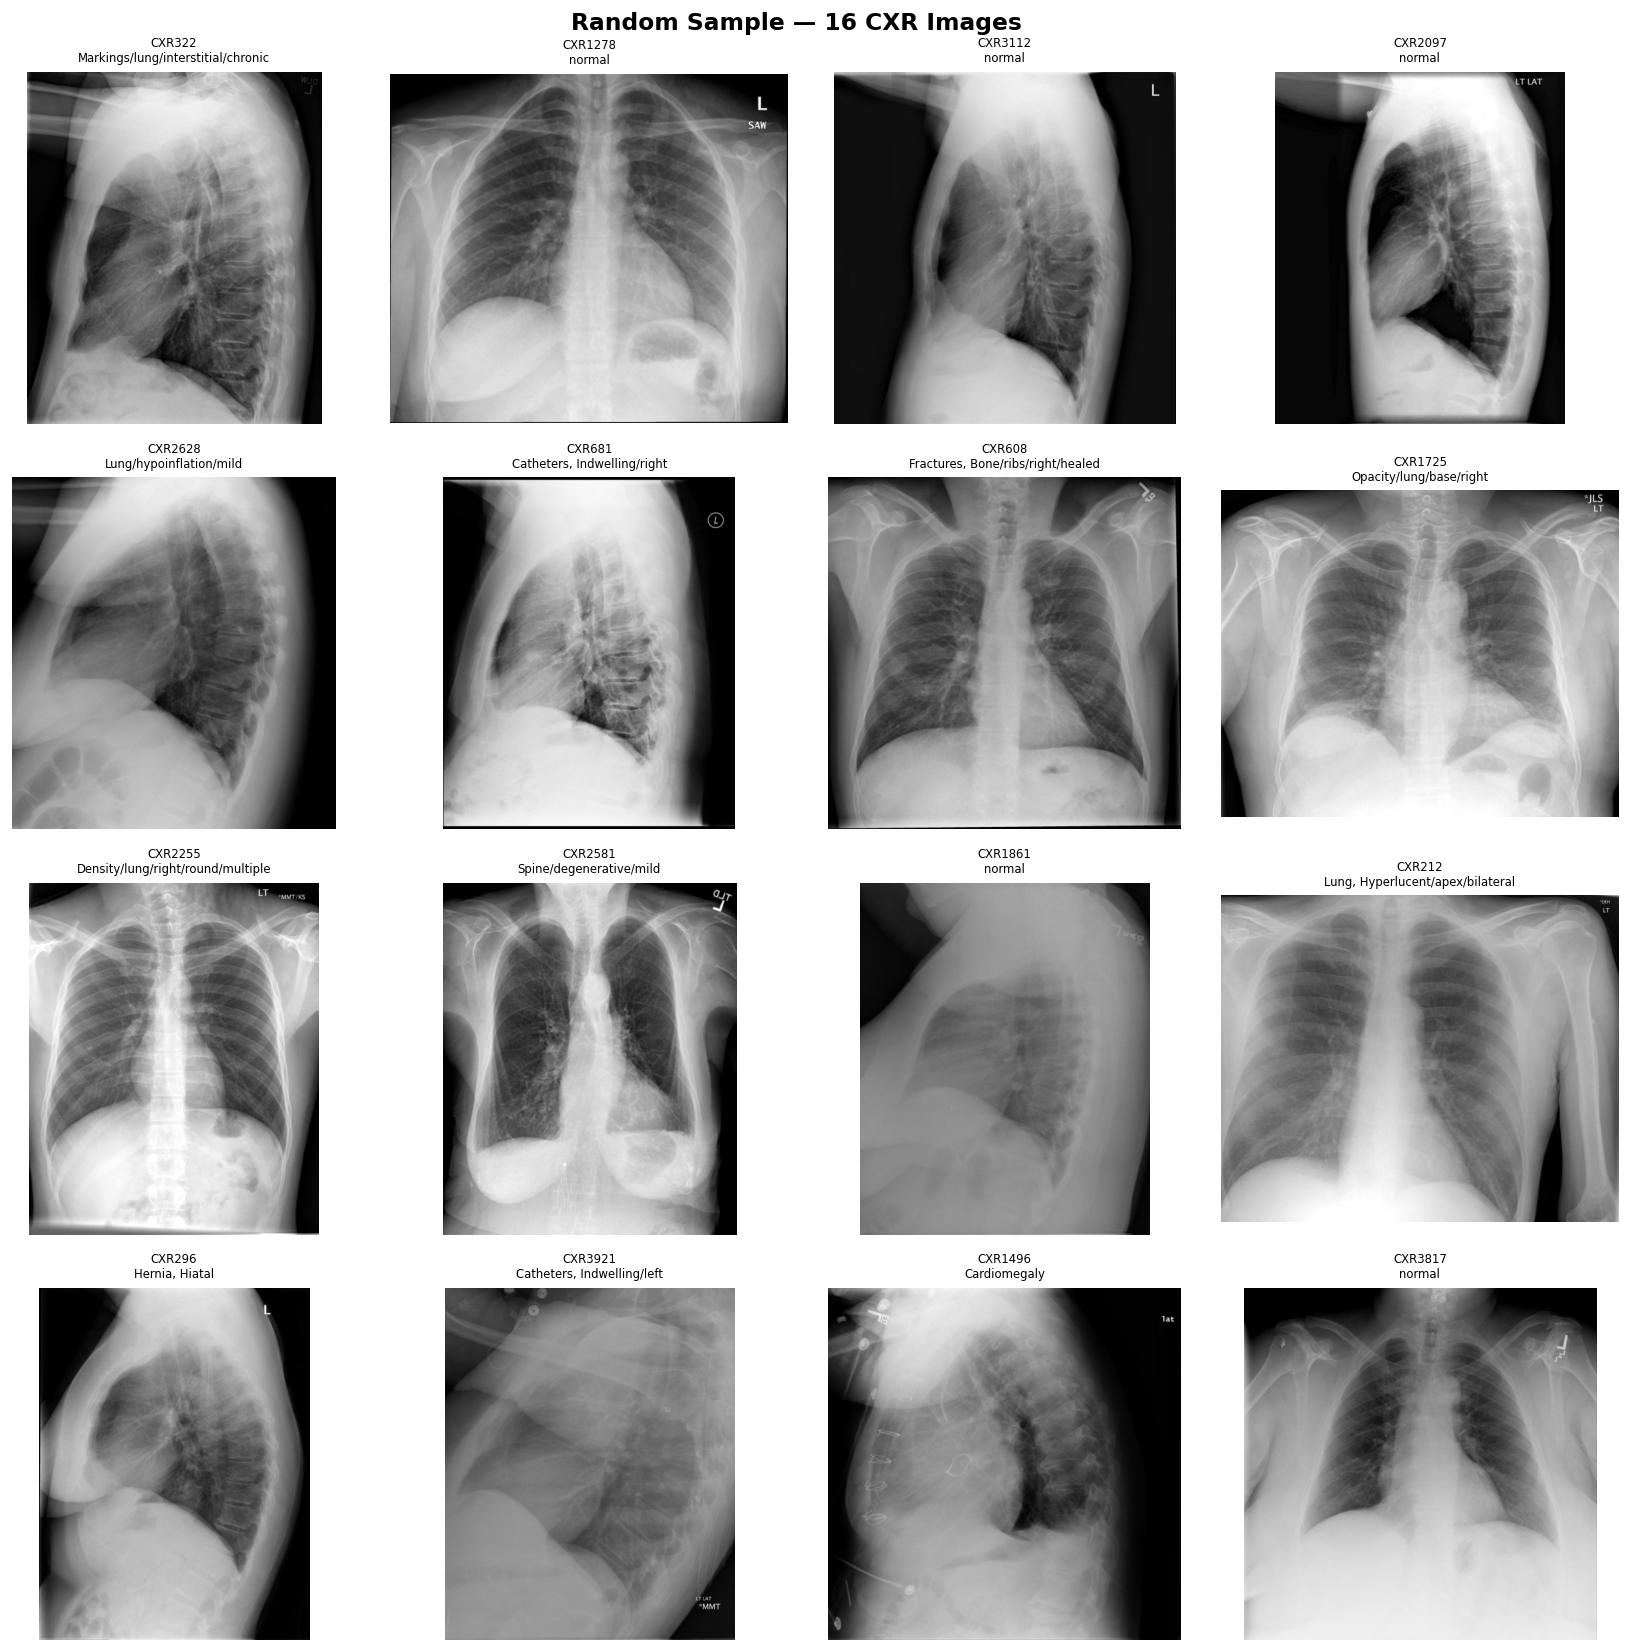

In [12]:
sample = df_flat[df_flat['image_path'].notna()].sample(16, random_state=42)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Random Sample — 16 CXR Images', fontsize=14, fontweight='bold')

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = imread(row['image_path'])
    ax.imshow(img, cmap='gray')
    # show UID + first mesh tag as title
    tag = row['mesh_major'][0] if row['mesh_major'] else 'n/a'
    ax.set_title(f"{row['uid']}\n{tag}", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4.4 Normal vs Abnormal split

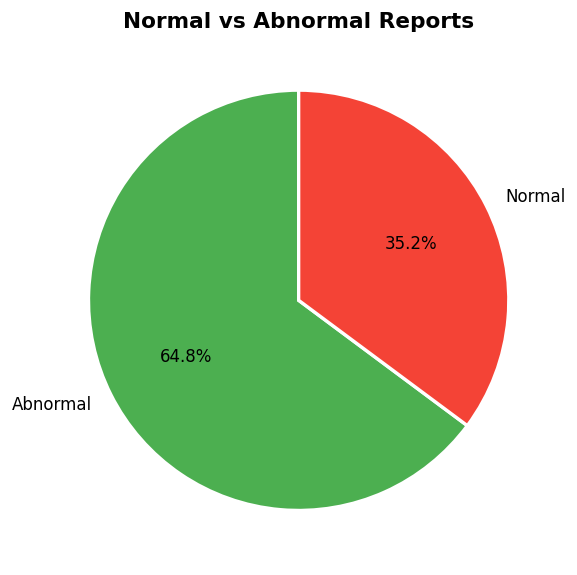

In [13]:
df['is_normal'] = df['mesh_major'].apply(lambda tags: 'normal' in [t.lower() for t in tags])
split = df['is_normal'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    split.values,
    labels=['Normal' if k else 'Abnormal' for k in split.index],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Normal vs Abnormal Reports', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Side-by-Side Image + Report Viewer

Use `view_case()` to inspect any sample.  
You can pass:
- `uid='CXR42'` — view by case UID  
- `index=100` — view by DataFrame row index  
- `image_id='CXR42_IM-...'` — view a specific image ID  

In [14]:
def view_case(uid: str = None, index: int = None, image_id: str = None,
              img_index: int = 0, figsize=(16, 7)):
    """
    Display a CXR image alongside its full radiology report.

    Parameters
    ----------
    uid       : case UID e.g. 'CXR42'
    index     : row index in df
    image_id  : specific parentImage id e.g. 'CXR42_IM-1234-1001'
    img_index : which image to show when a case has multiple (default 0 = first)
    """
    # ---- locate the row ----
    if uid is not None:
        rows = df[df['uid'] == uid]
        if rows.empty:
            # try matching the number part only
            rows = df[df['uid'].str.upper() == uid.upper()]
        if rows.empty:
            raise ValueError(f'UID "{uid}" not found. Sample UIDs: {df["uid"].sample(5).tolist()}')
        row = rows.iloc[0]
    elif index is not None:
        row = df.iloc[index]
    elif image_id is not None:
        rows = df[df['image_ids'].apply(lambda ids: image_id in ids)]
        if rows.empty:
            raise ValueError(f'image_id "{image_id}" not found.')
        row = rows.iloc[0]
        # override img_index to match the requested image
        img_index = row['image_ids'].index(image_id)
    else:
        row = df.sample(1).iloc[0]
        print(f'Random pick: uid={row["uid"]}')

    # ---- pick image ----
    if not row['image_paths']:
        print(f'No images found on disk for {row["uid"]}.')
        return
    img_index = min(img_index, len(row['image_paths']) - 1)
    img_path  = row['image_paths'][img_index]
    img_id    = row['image_ids'][img_index]

    # ---- build report text ----
    def section(label, text):
        if not text or text.strip() in ('', 'None', 'none'):
            return ''
        wrapped = '\n  '.join(wrap(text, width=65))
        return f'[{label}]\n  {wrapped}\n'

    report_text = (
        f'Case ID  : {row["uid"]}\n'
        f'Image ID : {img_id}'
        + (f'  ({img_index+1}/{len(row["image_paths"])} images)' if len(row['image_paths']) > 1 else '')
        + f'\nMeSH     : {" | ".join(row["mesh_major"]) or "—"}\n'
        + '─' * 55 + '\n'
        + section('INDICATION', row['indication'])
        + section('COMPARISON', row['comparison'])
        + section('FINDINGS',   row['findings'])
        + section('IMPRESSION', row['impression'])
    )

    # ---- plot ----
    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.1], wspace=0.04)

    # image panel
    ax_img = fig.add_subplot(gs[0])
    img = imread(img_path)
    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(f'{img_id}', fontsize=9, color='gray')
    ax_img.axis('off')

    # report panel
    ax_txt = fig.add_subplot(gs[1])
    ax_txt.axis('off')
    ax_txt.text(
        0.02, 0.98, report_text,
        transform=ax_txt.transAxes,
        fontsize=9.5,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f7f7f7', edgecolor='#cccccc', alpha=0.9)
    )

    fig.suptitle(f'Chest X-Ray Report  —  {row["uid"]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('view_case() ready.')
print('Usage examples:')
print('  view_case()              # random case')
print('  view_case(uid="CXR42")  # by UID')
print('  view_case(index=100)     # by DataFrame row')
print('  view_case(image_id="CXR42_IM-1234-1001")  # by image ID')

view_case() ready.
Usage examples:
  view_case()              # random case
  view_case(uid="CXR42")  # by UID
  view_case(index=100)     # by DataFrame row
  view_case(image_id="CXR42_IM-1234-1001")  # by image ID


### 5.1 — Random case

Random pick: uid=CXR3277


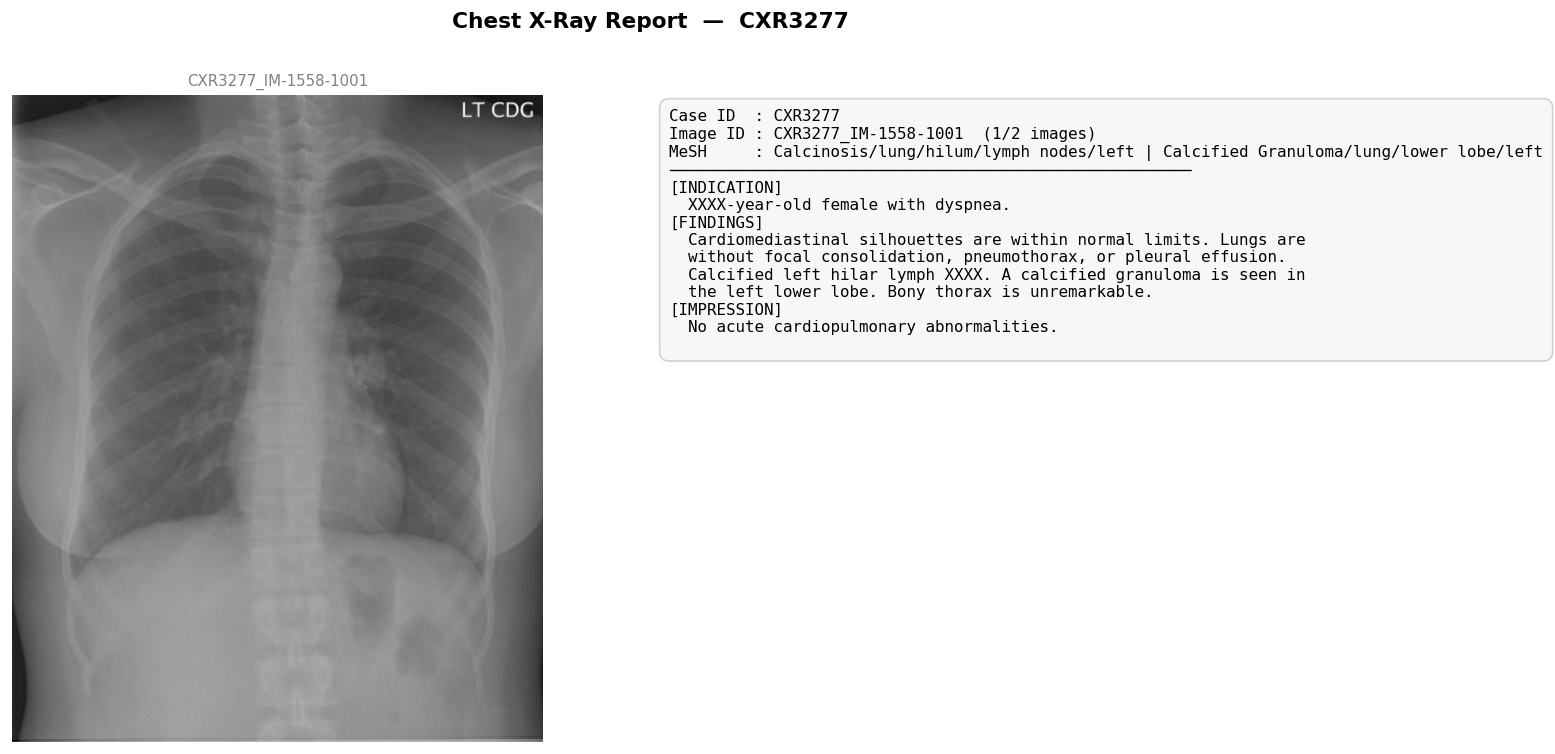

In [15]:
view_case()

### 5.2 — View by UID
Change `uid` to any case you want to inspect.

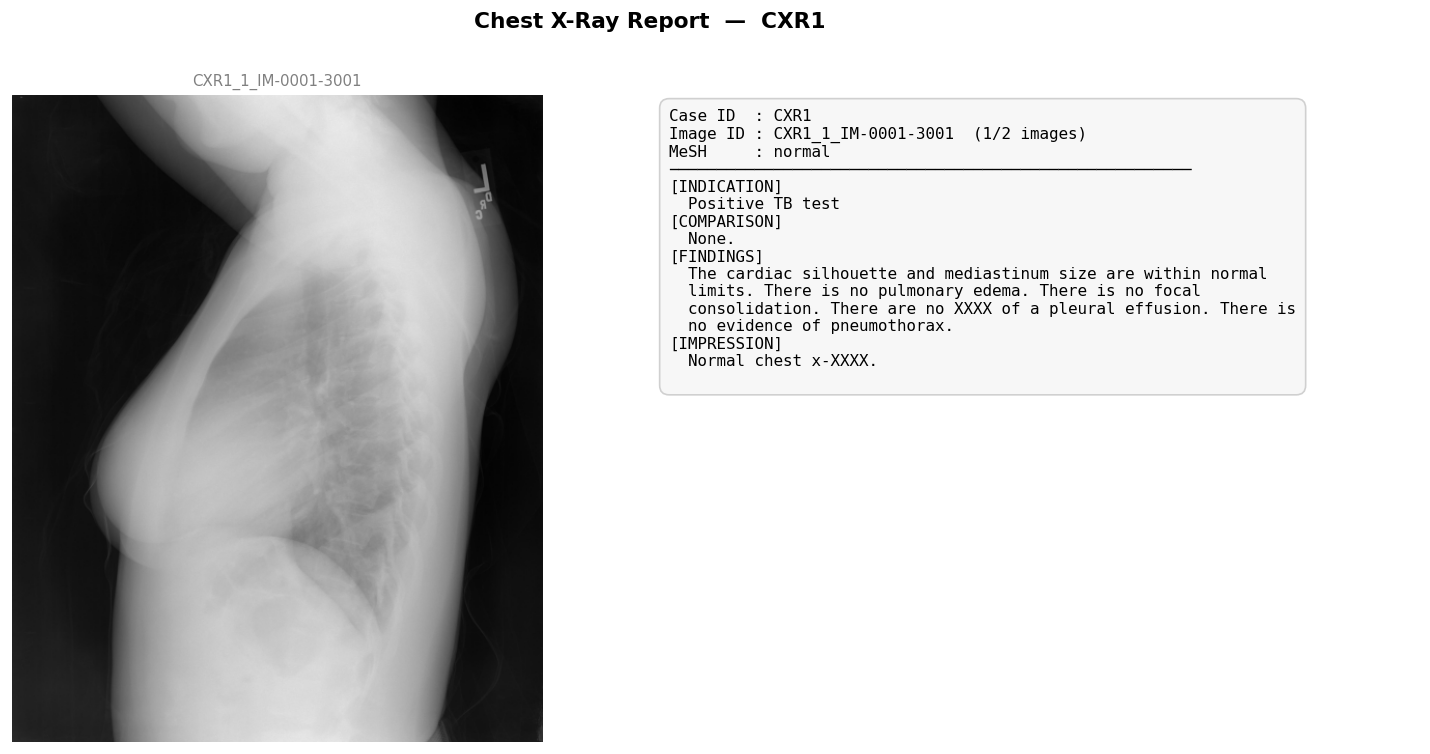

In [16]:
view_case(uid='CXR1')

### 5.3 — View by DataFrame row index

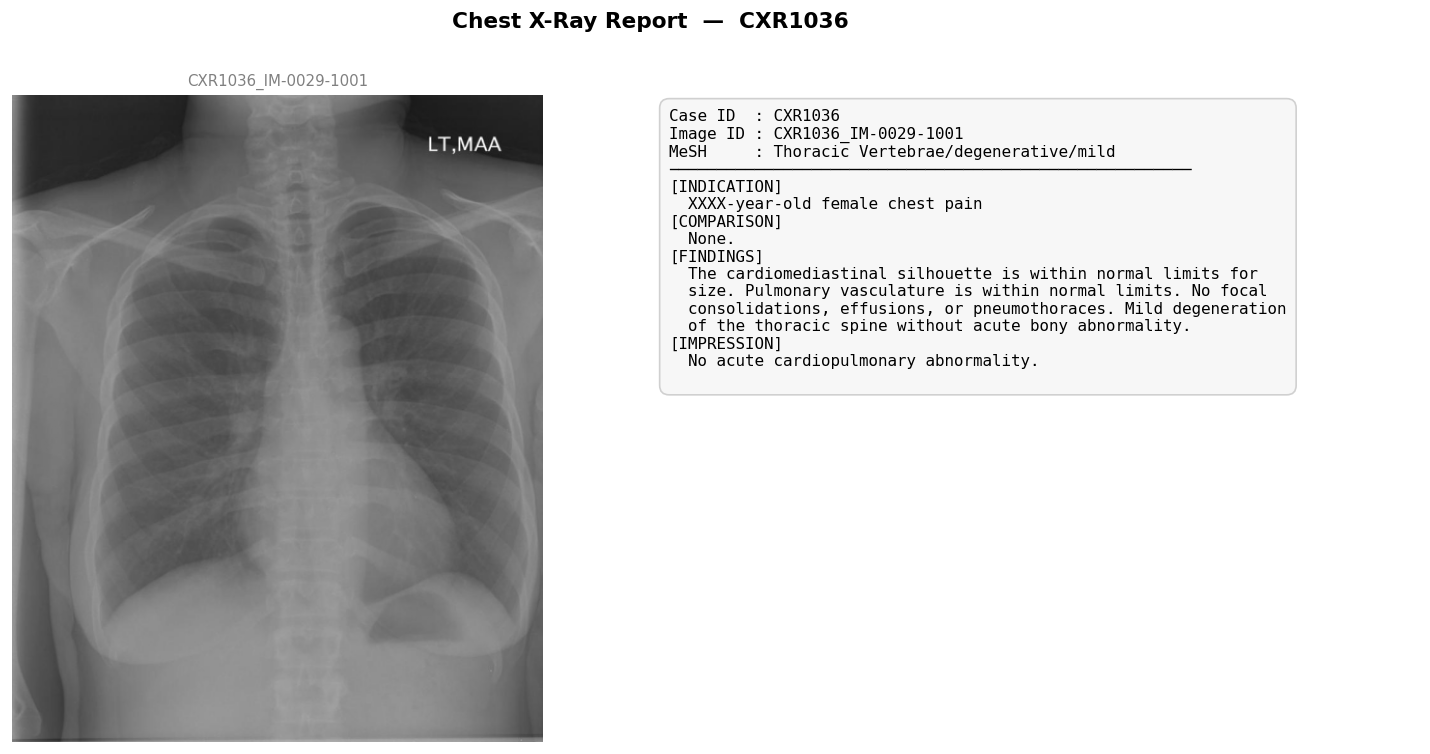

In [17]:
view_case(index=42)

### 5.4 — Browse multiple images of the same case

Cases with 2 images (PA + Lateral view) — use `img_index=0` or `img_index=1`.

Showing case: CXR1


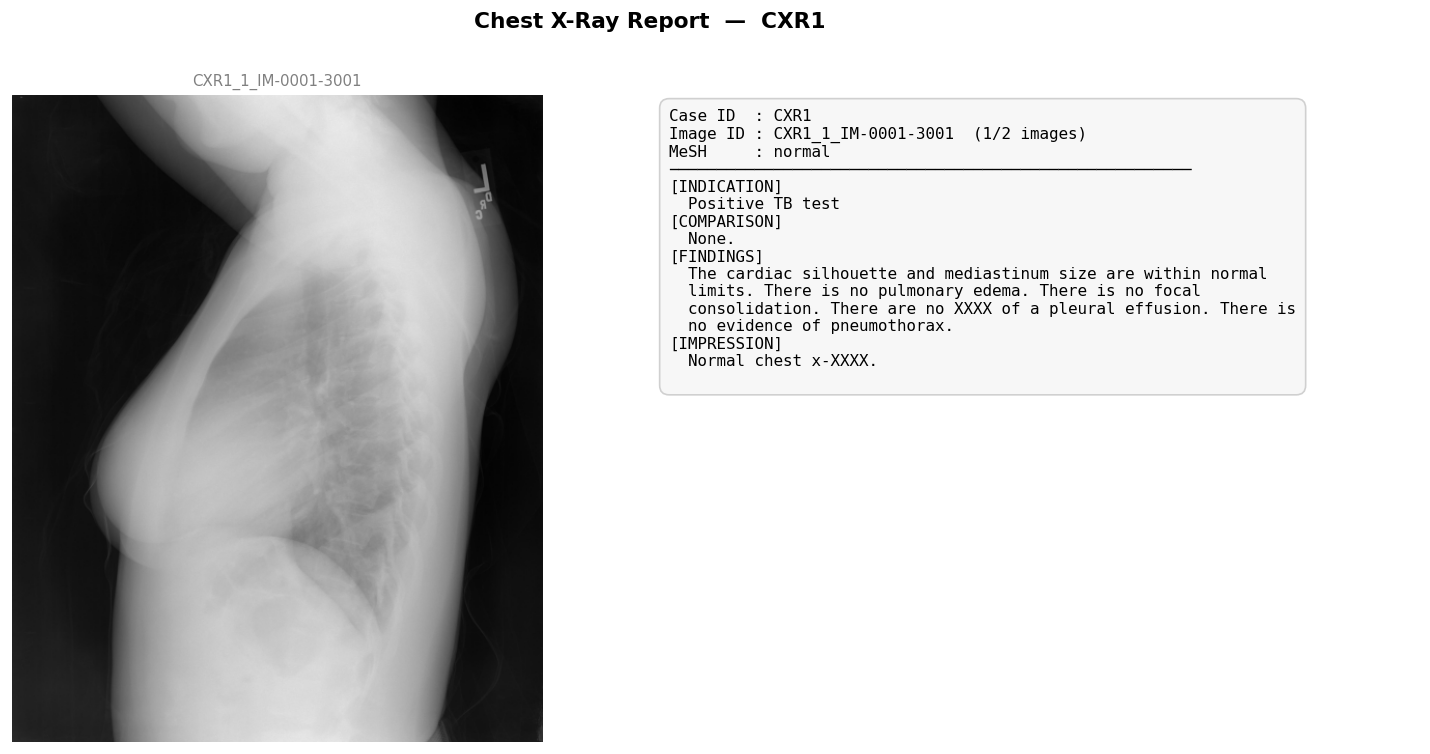

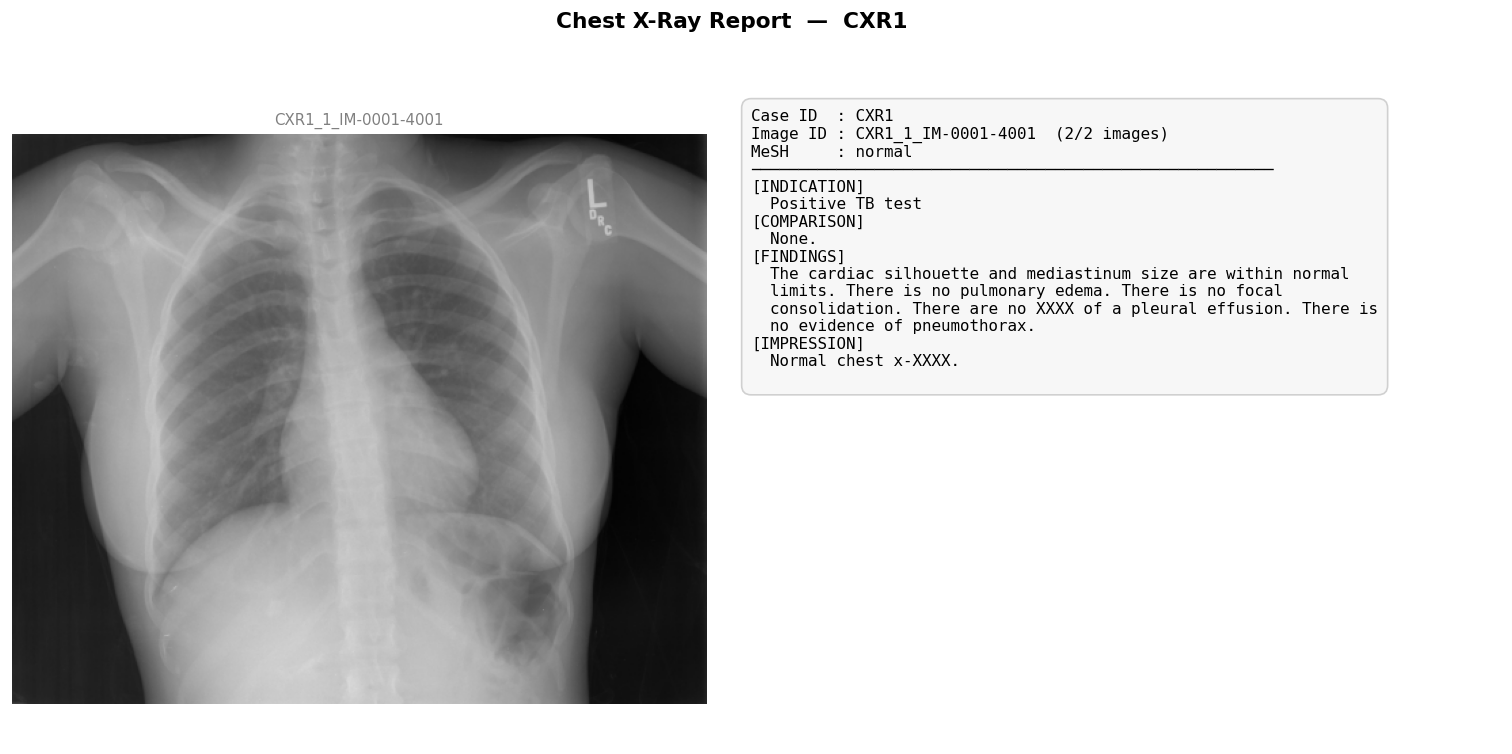

In [18]:
# find a case with 2 images
two_img_case = df[df['n_images'] == 2].iloc[0]['uid']
print(f'Showing case: {two_img_case}')
view_case(uid=two_img_case, img_index=0)   # first image (PA view)
view_case(uid=two_img_case, img_index=1)   # second image (Lateral view)

## 6 · Export DataFrame

Save the parsed dataset as CSV for downstream use.

In [19]:
csv_path = BASE_DIR / 'cxr_dataset.csv'

# Convert list columns to pipe-separated strings for CSV compatibility
df_export = df.copy()
df_export['mesh_major']  = df_export['mesh_major'].apply(lambda x: ' | '.join(x))
df_export['mesh_auto']   = df_export['mesh_auto'].apply(lambda x: ' | '.join(x))
df_export['image_ids']   = df_export['image_ids'].apply(lambda x: ' | '.join(x))
df_export['image_paths'] = df_export['image_paths'].apply(lambda x: ' | '.join(x))

df_export.to_csv(csv_path, index=False)
print(f'Saved → {csv_path}  ({len(df_export):,} rows)')

Saved → cxr_dataset.csv  (3,955 rows)
